# Introduction

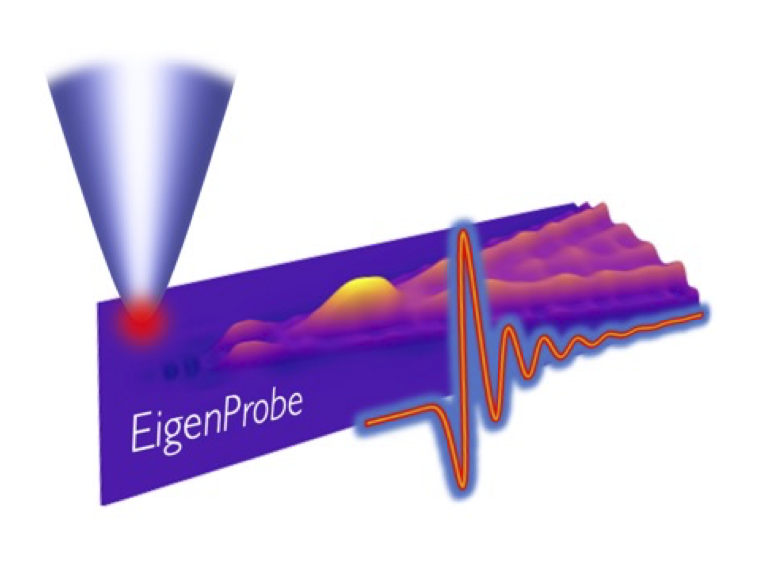

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

Here we will achieve the following goals.  Each of these calculations is a precondition for the subsequent one, and each one can be optionally loaded from file, recomputed, and saved.
* Build a probe around a standard conical geometry using a `Probe` object, compute its eigenmodes, and inspect its eigenvalues.
* Determine how eigenvalues disperse with probe-sample distance using a `ProbeGapSpectroscopy` object.  (We multi-thread this calculation using a `Parallel` version.)
* Build a compact description of the probe, its eigenfields, and their gap-dependence using a `EncodedEigenfields` object.
* Determine how eigenvalues disperse with excitation energy using a `ProbeFrequencySpectroscopy` object.  (We multi-thread this calculation using a `Parallel` version.)

# Imports

## General Imports

In [2]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload
import numpy as np

### Select matplotlib backend for 3D plot

In [3]:
%matplotlib inline

## Specialized Imports

In [4]:
from EigenProbe.common.baseclasses import AWA # https://github.com/asmcleod/common.git
from EigenProbe.common.misc import flatten
from EigenProbe.common import numerical_recipes as numrec

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

## EigenProbe tools

In [5]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Build probes

Here are some global parameters to describe the taper and length scales relevant to the probe(s).

In [6]:
a_nm=20 # probe radius
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming added cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle = 21
tan = np.tan(np.deg2rad(taper_angle))

WL_THz=300e-4 #300 microns wavelength
freq_THz=1/WL_THz
freq=30*freq_THz # 30 THz

Nsubnodes=2 # 2 or 4 are common values; can be any integer number, but greater than four gains questionably more accuracy and adds great expense.  Experience shows 2 is usually sufficient.
Nnodes=244 # 244 is a good balance of cost and accuracy.  The number will be coerced to the nearest available quadrature grid length.
EP.Probe.dtype = np.complex64

A custom function can build a probe geometry by specifying radius and z-height values for nodes along the body of revolution.

The default geometry starts out conical probe with "inverted" (concave) apex, but `rel_smoothing` is a tuning knob that can transform it into a blunt-face probe, and then to a sharp probe.

In [7]:
def get_geometry(rel_smoothing=None,N=int(1e4)):
    
    # Use radius as the independent vairable
    rmax = L*tan
    zs1 = np.linspace(0,L,100); rs1=a+zs1*tan
    rs2 = np.linspace(0,a,100)[1:-1]
    concavity = 0.5
    zs2 = np.sqrt(rs2.max()**2-rs2**2) * concavity
    rs = np.append(rs1,rs2)
    zs = AWA(np.append(zs1,zs2),axes=[rs]).sort_by_axes()
    rs_dense=np.linspace(rs.min(),rs.max(),N)
    zs_dense = zs.interpolate_axis(rs_dense,axis=0)
    
    if rel_smoothing:
        smoothing=N*rel_smoothing
        zs_dense = numrec.smooth(zs_dense,window_len=smoothing)

    return rs_dense,zs_dense

## Build two dissimilar pobes

<__init__._ProbesCollection.__setitem__>:
	Overwriting registered probe "Unconventional"...
<__init__.Probe.__init__>:
	Generating probe "Unconventional"...
<RotationalMoM.BodyOfRevolution.__init__>:
	Re-meshing provided geometry to quadrature points along annular coordinate `t`...
<RotationalMoM.BodyOfRevolution.__init__>:
	Discretizing body of revolution over 242 annular nodes and 2 subnodes...
<__init__._ProbesCollection.__setitem__>:
	Overwriting registered probe "Conventional"...
<__init__.Probe.__init__>:
	Generating probe "Conventional"...
<RotationalMoM.BodyOfRevolution.__init__>:
	Re-meshing provided geometry to quadrature points along annular coordinate `t`...
<RotationalMoM.BodyOfRevolution.__init__>:
	Discretizing body of revolution over 242 annular nodes and 2 subnodes...


Text(0.5, 1.0, 'Conventional')

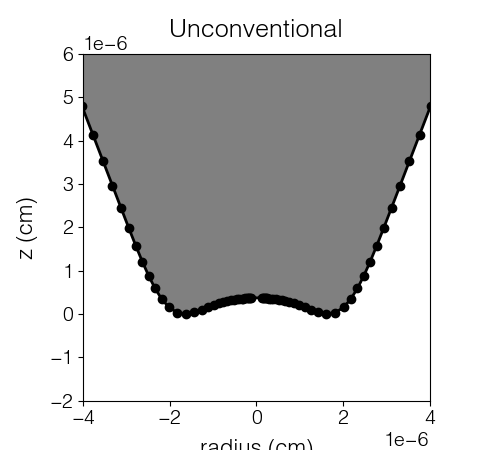

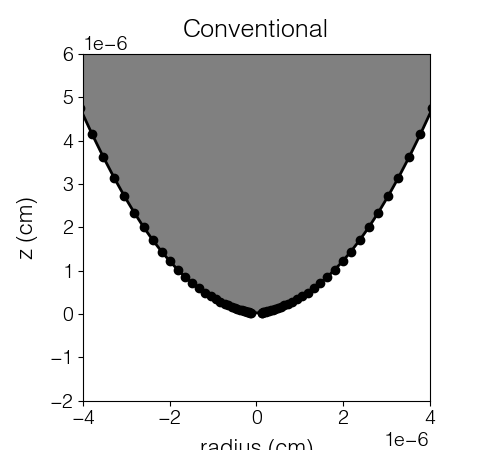

In [12]:
probe_name1='Unconventional'
rs,zs=get_geometry(rel_smoothing=3e-3,N=int(1e4))
zs -= zs.min()
P1=EP.Probe(a=a,rs=rs,zs=zs,
           remesh=True,Nnodes=Nnodes,quadrature=numrec.TS,
           freq=freq,gap=a,name=probe_name1)

P1.plot_geometry()
plt.xlim(-2*a,2*a)
plt.ylim(-a,3*a)
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')
plt.title(probe_name1)

probe_name2='Conventional'
rs,zs=get_geometry(rel_smoothing=1.2e-2,N=int(1e4))
zs -= zs.min()
P2=EP.Probe(a=a,rs=rs,zs=zs,
           remesh=True,Nnodes=Nnodes,quadrature=numrec.TS,
           freq=freq,gap=a,name=probe_name2)

P2.plot_geometry()
plt.xlim(-2*a,2*a)
plt.ylim(-a,3*a)
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')
plt.title(probe_name2)

#Zmirror = P.get_mirror_impedance(k=P.get_k(),nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=0,nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=P.get_k(),farfield=False,recompute=True,sommerfeld=True,Nkappas=244*8,rp=rp_au,\
#                                kappa_min=P.get_k()*.01)

## Visualize one of the probe apices in 3D

In [9]:
# switch into 3D support
%matplotlib widget

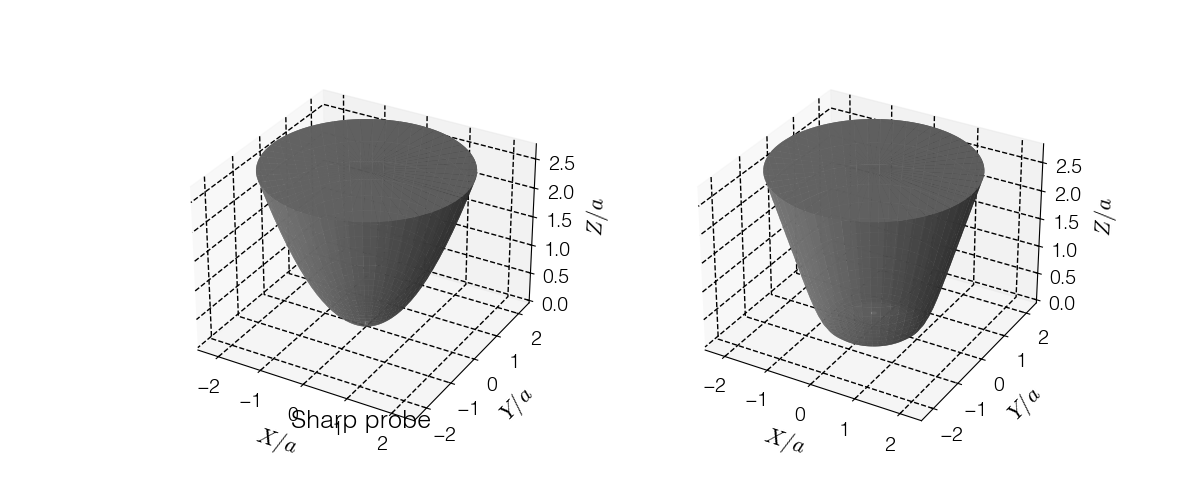

Text(0.5, 0.0, 'Blunt probe')

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

#--- Probe 2

zs = P2.get_zs()
rs = P2.get_radii()
a = P2.get_a()

zspan = 3*a; view=zs<zspan
zs = zs[view]
rs = rs[view]

thetas=np.linspace(0,2*np.pi,100)[np.newaxis,:]
stride=1
Zs=np.append(zs[::stride],np.max(zs))
Rs=np.append(rs[::stride],0)
Z_3D=Zs[:,np.newaxis]
X_3D =Rs[:,np.newaxis]*np.cos(thetas)
Y_3D = Rs[:,np.newaxis]*np.sin(thetas)

# 5. Plot using Matplotlib 3D
ax1.plot_surface(X_3D/a, Y_3D/a, Z_3D/a, color='gray', alpha=0.9, shade=True)

ax1.set_xlabel(r"$X/a$")
ax1.set_ylabel(r"$Y/a$")
ax1.set_zlabel(r"$Z/a$")

ax1.set_title("Sharp probe", y=0)

#--- Probe 1

zs = P1.get_zs()
rs = P1.get_radii()
a = P1.get_a()

zspan = 3*a; view=zs<zspan
zs = zs[view]
rs = rs[view]

thetas=np.linspace(0,2*np.pi,100)[np.newaxis,:]
stride=1
Zs=np.append(zs[::stride],np.max(zs))
Rs=np.append(rs[::stride],0)
Z_3D=Zs[:,np.newaxis]
X_3D =Rs[:,np.newaxis]*np.cos(thetas)
Y_3D = Rs[:,np.newaxis]*np.sin(thetas)

# 5. Plot using Matplotlib 3D
ax2.plot_surface(X_3D/a, Y_3D/a, Z_3D/a, color='gray', alpha=0.9, shade=True)

ax2.set_xlabel(r"$X/a$")
ax2.set_ylabel(r"$Y/a$")
ax2.set_zlabel(r"$Z/a$")
plt.show()

ax2.set_title("Blunt probe", y=0)

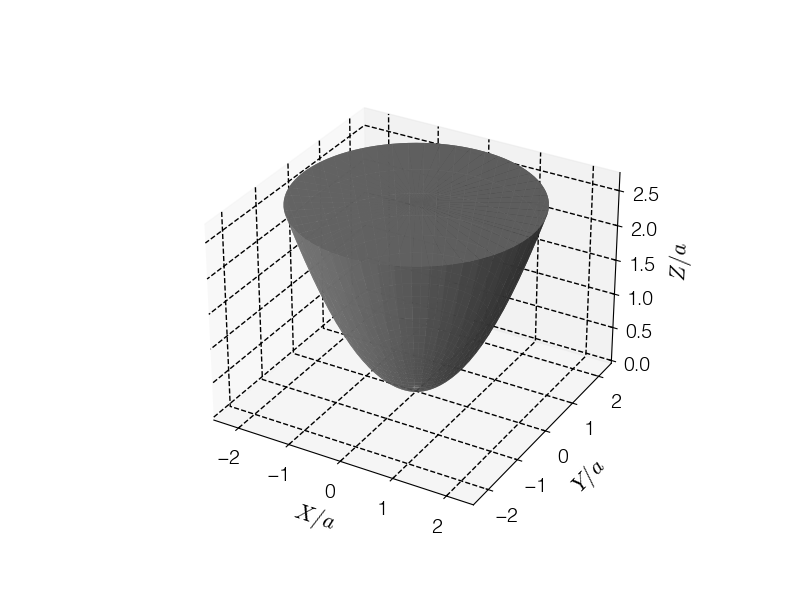

In [14]:
zs = P2.get_zs()
rs = P2.get_radii()
a = P2.get_a()

zspan = 3*a; view=zs<zspan
zs = zs[view]
rs = rs[view]

thetas=np.linspace(0,2*np.pi,100)[np.newaxis,:]
stride=1
Zs=np.append(zs[::stride],np.max(zs))
Rs=np.append(rs[::stride],0)
Z_3D=Zs[:,np.newaxis]
X_3D =Rs[:,np.newaxis]*np.cos(thetas)
Y_3D = Rs[:,np.newaxis]*np.sin(thetas)

# 5. Plot using Matplotlib 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X_3D/a, Y_3D/a, Z_3D/a, color='gray', alpha=0.9, shade=True)

ax.set_xlabel(r"$X/a$")
ax.set_ylabel(r"$Y/a$")
ax.set_zlabel(r"$Z/a$")
plt.show()

In [12]:
# switch out of the 3D support
%matplotlib inline

## Compute and compare eigenmodes

The probe is ready to compute interactions with a sample only once its gap distance `d` is set, and once is self-($\omega$-specific) and mirror-($d$-specific) impedance matrices are computed.  The former is computed (`Probe.get_self_impedance`) by adaptive quadrature as a superposition of "Green functions" from each axisymmetric "pulse" basis element along the exterior of the probe's length. (The probe is assumed a perfect conductor, with no internal degrees of freedom.)  The latter is by default also computed (`Probe.get_mirror_impedance`) by adaptive quadrature, or instead with sommerfeld integrals (keyword `sommerfeld=True`); the latter demands a quadrature grid of $\kappa$ values specifiable by `Nkappas` that alternatively defaults to a (naive) best-guess Tanh-Sinh quadrature grid.  The Sommerfeld calculation is faster but convergence must be carefully checked and is not guaranteed for arbitrary geometries.  By contrast, adaptive quadrature calculations should be accurate to machine precision (up to maximum evaluations set by `RotMOM.quadlimit`); fundamental inaccuracies owe to the finite number of "nodes" along the probe. 

Once these impedance matrices are computed, eigenmodes (values $\rho_\nu$ and corresponding vectors $Q_\nu$) are obtained as solutions to the generalized eigenvalue problem described by self- and mirror-impedances.  To obtain the eigenmodes, use `Probe.solve_eigenmodes` with optional conditioning (coercion to positive-definiteness) of the impedance matrices.  The eigenvalues $rho_\nu$ are visualized by `Probe.plot_eigenrhos`; physically meaningful (spatially confined and radiative) eigenmodes have positive real and negative imaginary parts of $\rho_nu$.

In [13]:
RotMOM.quadlimit = int(1e4) # maximum evaluations of interaction kernel per node of probe

# Select a close probe-sample distance, at which the eigenmodes become quite different for the dissimilar two probes.
d=.1*a

P1.set_gap(d)
Zmirror1 = P1.get_mirror_impedance(sommerfeld=False)
rhos1,Js1 = P1.solve_eigenmodes(condition_ZM=True,condition_ZS=False,ZMthresh=0,recompute_impedance=False,plot=False) # Do not plot eigenvalues of the mirror impedance.

P2.set_gap(d)
Zmirror2 = P2.get_mirror_impedance(sommerfeld=False)
rhos2,Js2 = P2.solve_eigenmodes(condition_ZM=True,condition_ZS=False,ZMthresh=0,recompute_impedance=False,plot=False)

<RotationalMoM.ImpedanceMatrix>:
	Preparing quasistatic mirror impedance matrix at k=0...
	Progress: 99.59%	Total quadrature time: 2.80s, time per quadrature evaluation: 4.78E-05s
<RotationalMoM.ImpedanceMatrix>:
	Preparing dynamic self impedance matrix at k=6.3E+03...
	Progress: 99.59%	Total quadrature time: 8.75s, time per quadrature evaluation: 1.49E-04s
<RotationalMoM.ImpedanceMatrix>:
	Preparing quasistatic mirror impedance matrix at k=0...
	Progress: 99.59%	Total quadrature time: 2.19s, time per quadrature evaluation: 3.73E-05s
<RotationalMoM.ImpedanceMatrix>:
	Preparing dynamic self impedance matrix at k=6.3E+03...
	Progress: 99.59%	Total quadrature time: 9.07s, time per quadrature evaluation: 1.55E-04s


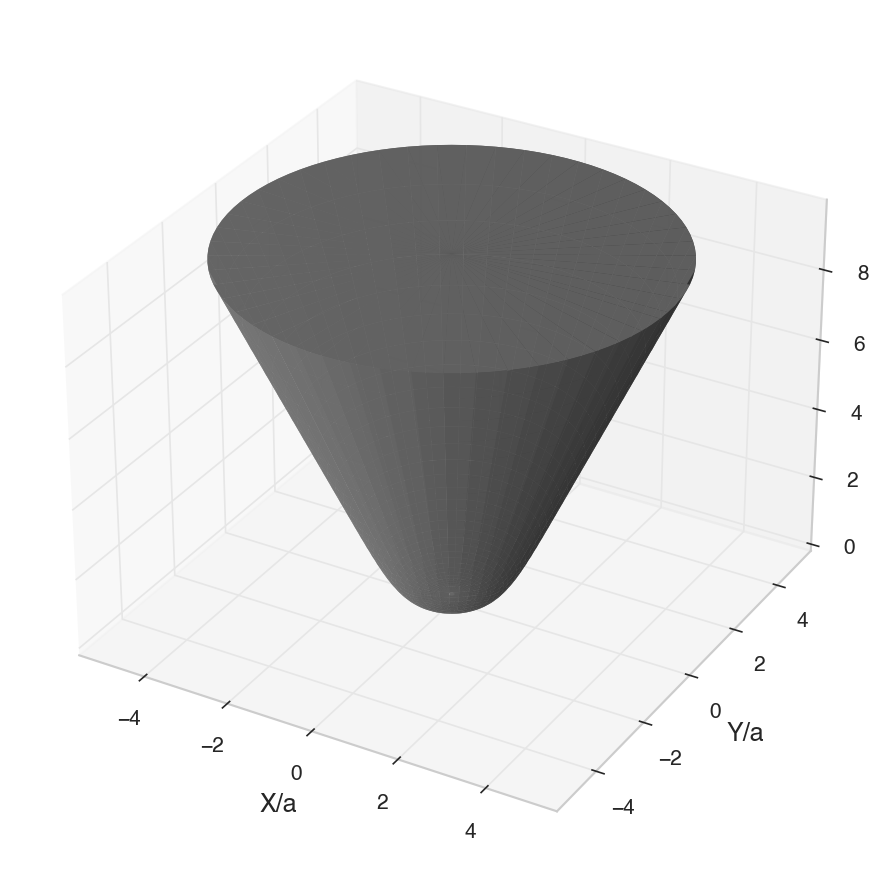

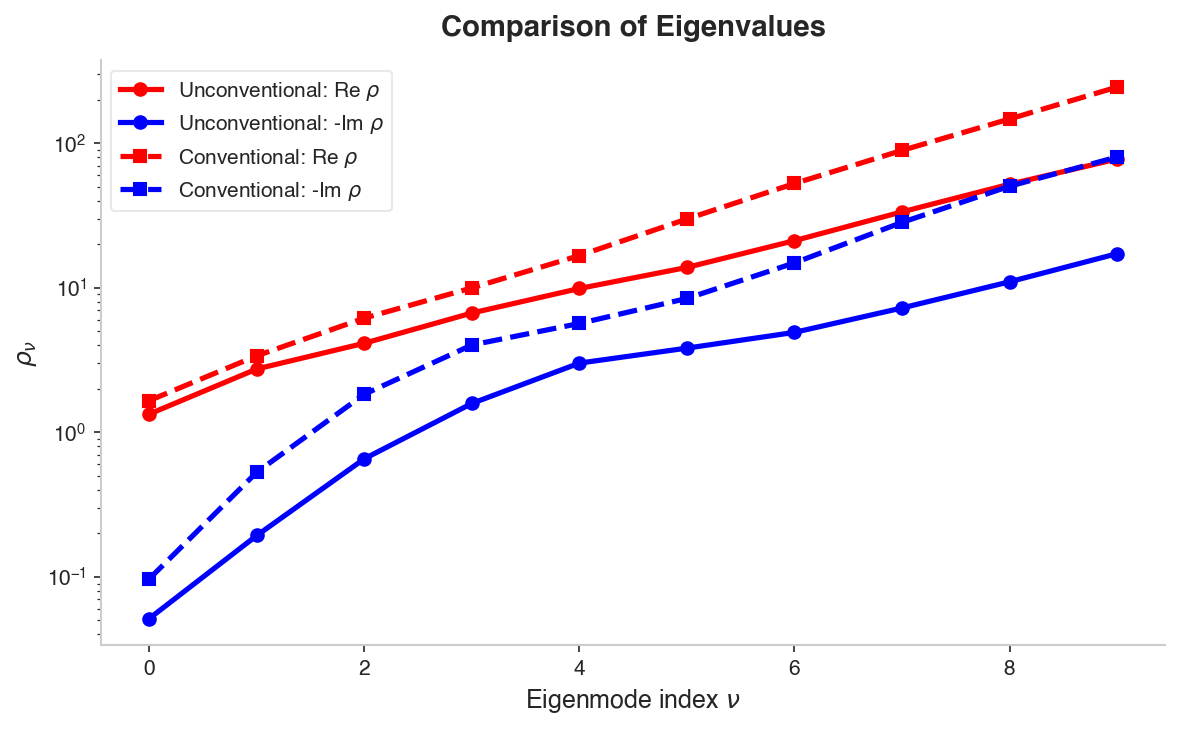

In [14]:
plt.figure()
N=10 # Plot this many eigenvalues
plt.semilogy(rhos1.real[:N],marker='o',color='r',label=r'%s: Re $\rho$'%probe_name1)
plt.semilogy(-rhos1.imag[:N],marker='o',color='b',label=r'%s: -Im $\rho$'%probe_name1)

plt.semilogy(rhos2.real[:N],marker='s',color='r',ls='--',label=r'%s: Re $\rho$'%probe_name2)
plt.semilogy(-rhos2.imag[:N],marker='s',color='b',ls='--',label=r'%s: -Im $\rho$'%probe_name2)

plt.legend()
plt.title('Comparison of Eigenvalues')
plt.xlabel(r'Eigenmode index $\nu$')
plt.ylabel(r'$\rho_\nu$')
plt.grid()

# Predict and compare s-SNOM spectroscopies from both probes

In [15]:
from EigenProbe import Materials as M # Be sure to import this *after* building probes.  Otherwise `sympy` import here can clash with previous compilation with `numba`.

# Suppose a spectroscopy experiment is conducted over `target_material`, followed by normalization over `norm_material`.
target_material = M.SiO2_300nm
norm_material = M.Si 

freqs_wn = np.linspace(700,1400,200) # Probing energies (in wavenumbers) that span the SiO2 phonon

<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

In [16]:
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 4*a_nm # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
kappa_max=None #20/P.get_a() # Largest value of in-plane momentum (in Probe units) to use for internal momentum quadrature with Fresnel coefficient
Nkappas = 122 # Number of momentum quadrature points to use by default
Ngaps = 24 # Number of probe-sample gap nodes to use for computing demodulated scattering
Nmodes_compute = 30 # Number of eigenmodes to use in the simulation.  Typically only the lowest 10 matter.

kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes_compute)

In [17]:
spectroscopy1 = P1.getNormalizedSignal(freqs_wn=freqs_wn,
                                             rp=target_material.reflection_p,
                                            rp_norm=norm_material.reflection_p,
                                            norm_single_freq=True,
                                         **kwargs)
spectroscopy2 = P2.getNormalizedSignal(freqs_wn=freqs_wn,
                                             rp=target_material.reflection_p,
                                            rp_norm=norm_material.reflection_p,
                                            norm_single_freq=True,
                                         **kwargs)

amplitude= 8e-06
gapmin= 2e-07
<__init__.Probe.get_eigenbrightness>:
	Computing eigenbrightness at k=6283.19...
<__init__.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=700.5220685338898...
<__init__.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=704.0422799335576...
<__init__.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=707.5624913332254...
<__init__.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=711.0827027328932...
<__init__.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.Erad

Text(0.5, 1.0, 'Comparison of non-normalized spectroscopy')

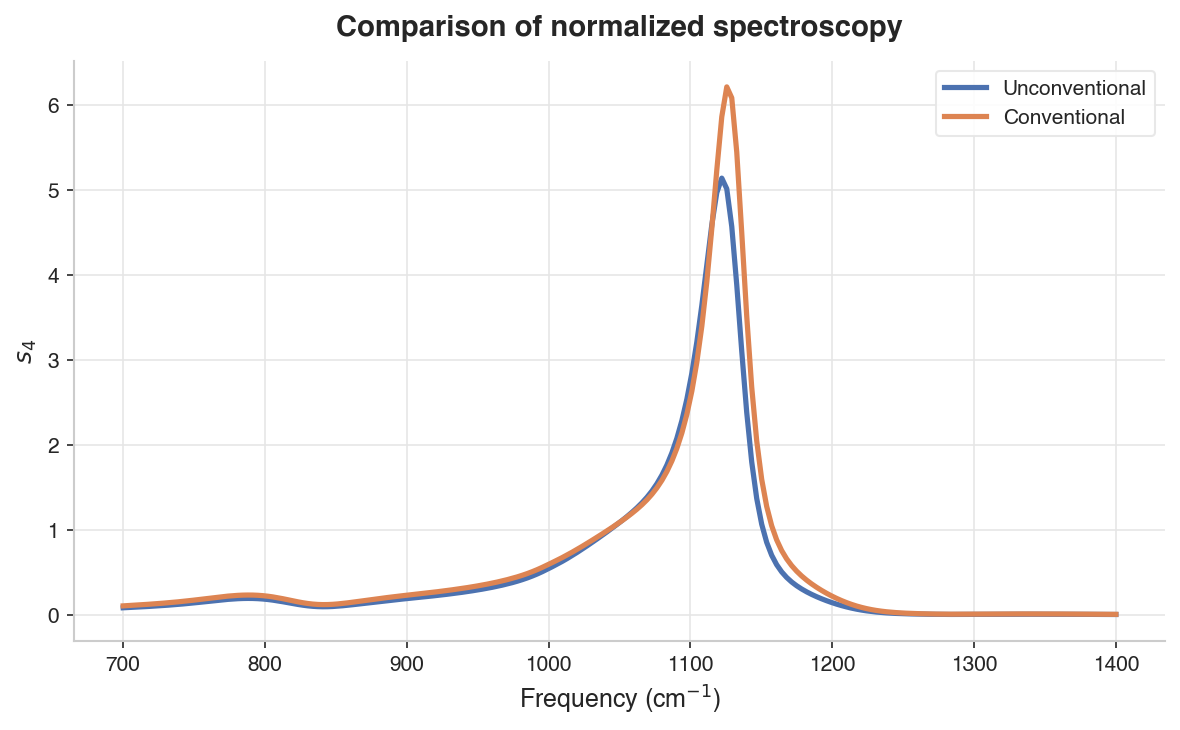

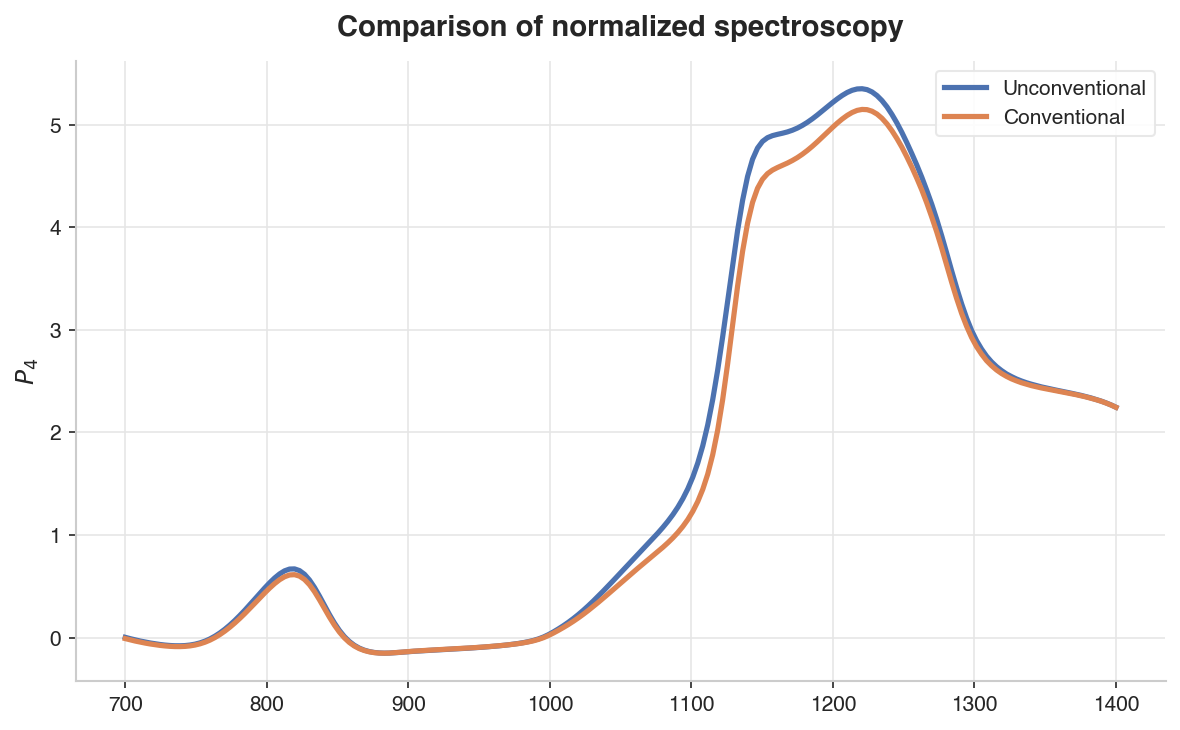

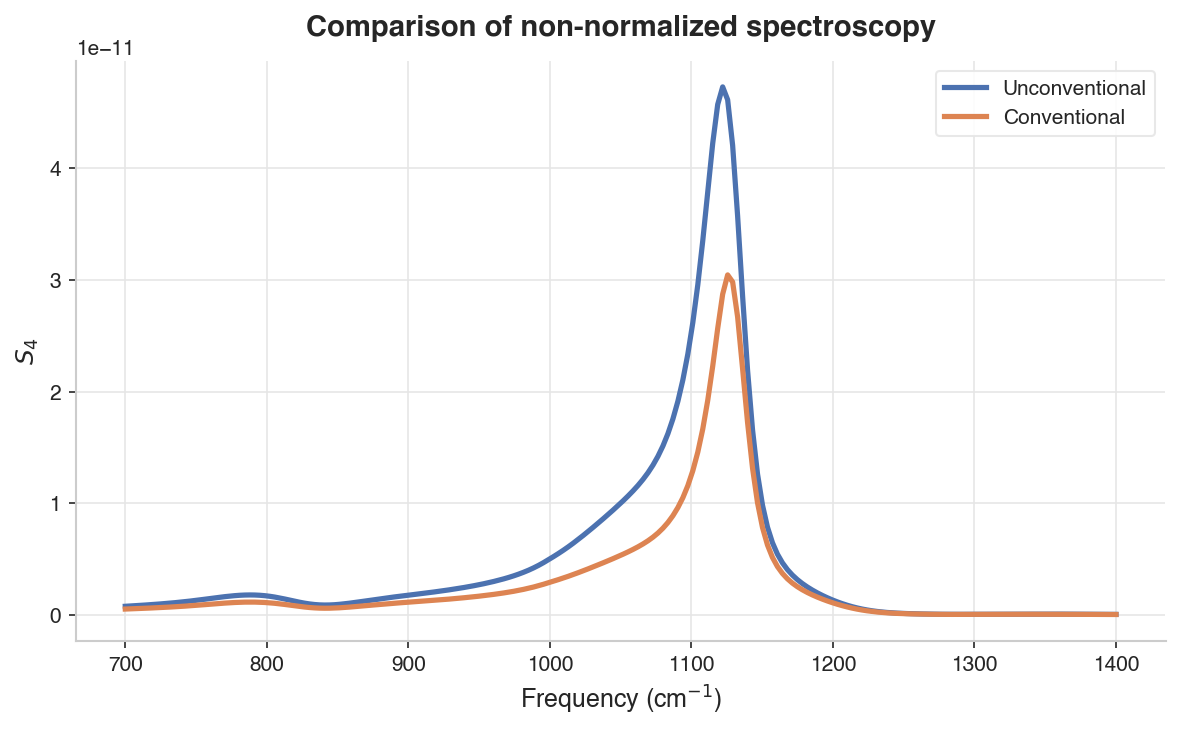

In [18]:
harmonic=4

plt.figure()
np.abs(spectroscopy1['Sn_norm'][harmonic]).plot(label=probe_name1)
np.abs(spectroscopy2['Sn_norm'][harmonic]).plot(label=probe_name2)
plt.legend()
plt.ylabel(r'$s_%i$'%harmonic)
plt.title('Comparison of normalized spectroscopy')

plt.figure()
p1 = np.unwrap(np.angle(spectroscopy1['Sn_norm'][harmonic]))
p2 = np.unwrap(np.angle(spectroscopy2['Sn_norm'][harmonic]))
plt.plot(freqs_wn,p1,label=probe_name1)
plt.plot(freqs_wn,p2,label=probe_name2)
plt.legend()
plt.ylabel(r'$P_%i$'%harmonic)
plt.title('Comparison of normalized spectroscopy')


plt.figure()
np.abs(spectroscopy1['Sn'][harmonic]).plot(label=probe_name1)
np.abs(spectroscopy2['Sn'][harmonic]).plot(label=probe_name2)
plt.legend()
plt.ylabel(r'$S_%i$'%harmonic)
plt.title('Comparison of non-normalized spectroscopy')

We can conclude that:
* The unconventional (blunt) probe provides higher overall scattering from its eigenmodes, since lower eigenvalues imply they are more strongly excited.
* This is consistent higher field z-confinement by the blunt probe.
* But the conventional (sharp) probe provides higher relative contrast between the target and normalization materials.
* This is because for the sharp probe, (real part of) eigenvalues approach unity more "steeply" with probe-sample distance, whcih is the dominant relative contrast mechanism.